# Thermostat Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.6` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton for further how this is implemented please have a look at the bouncing ball source code in `hybrid_automatons` pkg.

![Traffic Lights Diagram](https://github.com/rymc-dev/hybrid-automaton/blob/stable/notebooks/figures/traffic_lights_hybrid_automaton.png)

In [1]:
import os
import numpy as np

from hybrid_automatons import traffic_lights
from hybrid_automaton import Automaton
from hybrid_automaton import RunResult

In [2]:
ha: Automaton = traffic_lights(
    time_in_green=8.0,
    time_in_yellow=3.0,
    time_in_red=5.0
)
print (ha)

Hybrid Automaton Definition:
	name: Traffic Light Automaton
	id: 0
	initial_mode: RED
	modes: [RED, GREEN, YELLOW]
	transitions:
		RED --[red_to_green]--> GREEN
		GREEN --[green_to_yellow]--> YELLOW
		YELLOW --[yellow_to_red]--> RED
	guards:
		red_to_green: [red_to_green_guard]
		green_to_yellow: [green_to_yellow_guard]
		yellow_to_red: [yellow_to_red_guard]
	resets:
		red_to_green: <none>
		green_to_yellow: <none>
		yellow_to_red: <none>
	invariants:
		RED: [<none>]
		GREEN: [<none>]
		YELLOW: [<none>]
	continous_dynamics:
		RED -> <none>
		GREEN -> <none>
		YELLOW -> <none>



In [3]:
print (f"Hybrid Automaton `.mmd` diagram: \n\n{repr(ha)}",)

Hybrid Automaton `.mmd` diagram: 

stateDiagram-v2
    direction LR
    [*] --> RED
    RED --> GREEN: red_to_green
    GREEN --> YELLOW: green_to_yellow
    YELLOW --> RED: yellow_to_red


In [4]:
results: RunResult = await ha.activate(
    initial_continuous_state = None, 
    enable_real_time_mode=False, 
    enable_self_integration=True, 
    timeout_sec=40.0, 
    delta_time=0.01, 
    continuous_state_sampler_enabled=True,
    continuous_state_sampler_rate=0.01,
    control_input_states_sampler_enabled=True,
    control_input_states_sampler_rate=1
)

🟢 GREEN LIGHT - Go!
🟡 YELLOW LIGHT - Caution!
🔴 RED LIGHT - Stop!
🟢 GREEN LIGHT - Go!
🟡 YELLOW LIGHT - Caution!
🔴 RED LIGHT - Stop!
🟢 GREEN LIGHT - Go!


In [5]:
print (results)

Automaton Run Summary
Run ID: 20260206T125757Z_3fcc69
Status: TIMEOUT
logs directory: ./log_hybrid_automaton/

Termination:
  Code: CANCELLED
  Message: Timeout exceeded
  Final State: GREEN

Execution Metrics:
  Total Runtime: 4.650s
  Total Steps: 4018
  Transitions: 7

Step Statistics:
  NORMAL: 4011
  TRANSITION: 7


/home/ryan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


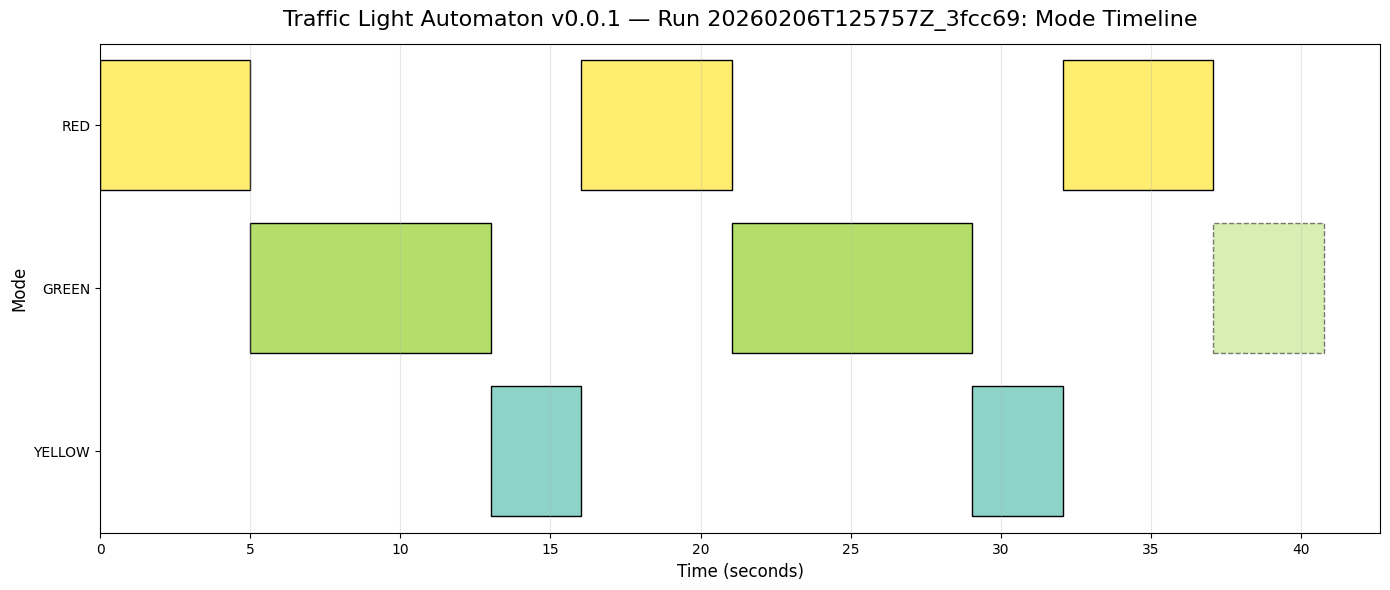

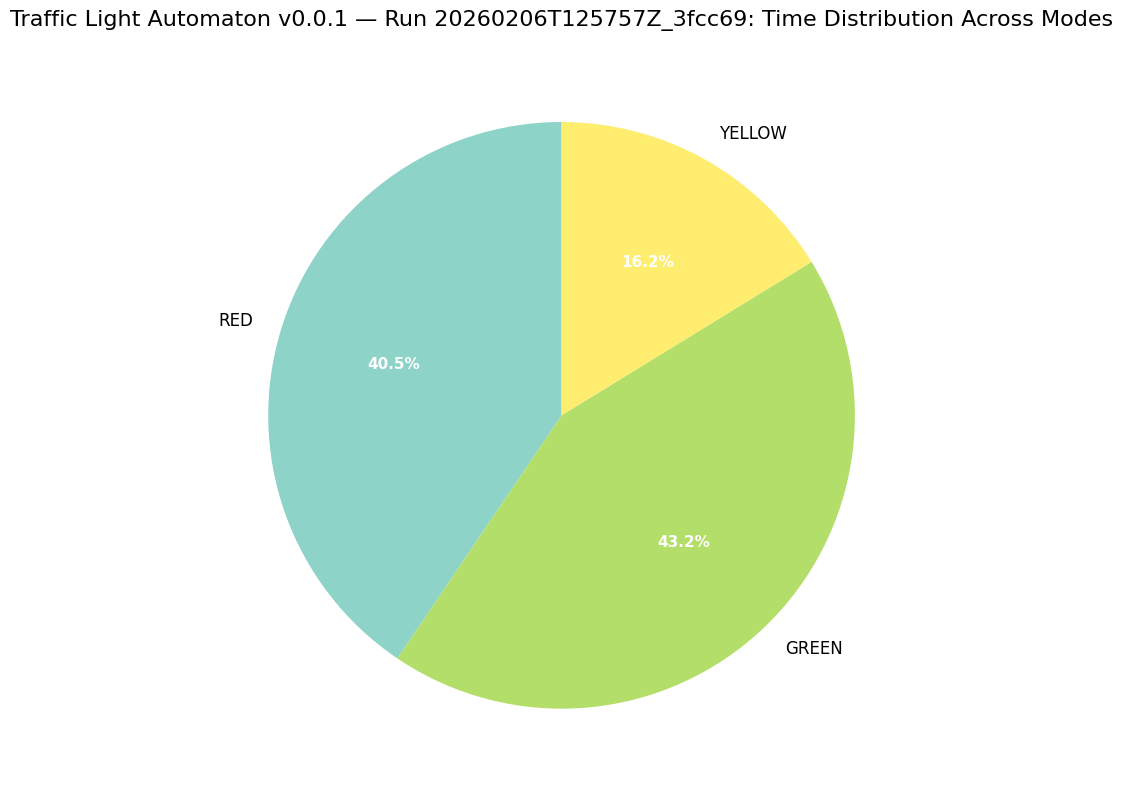

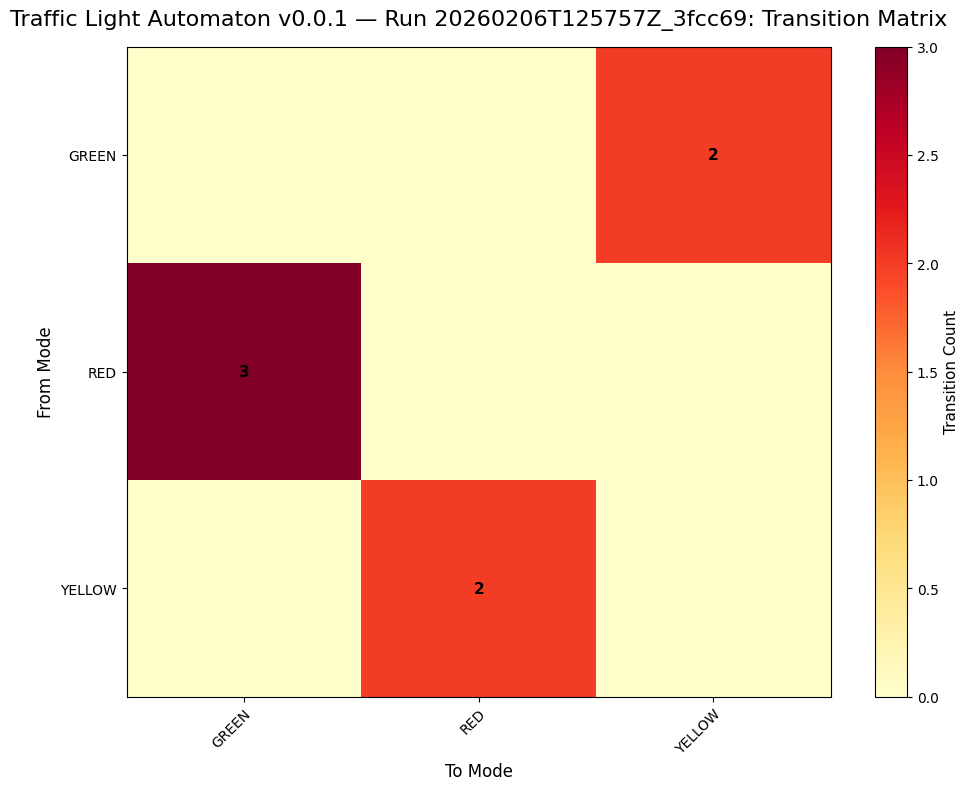

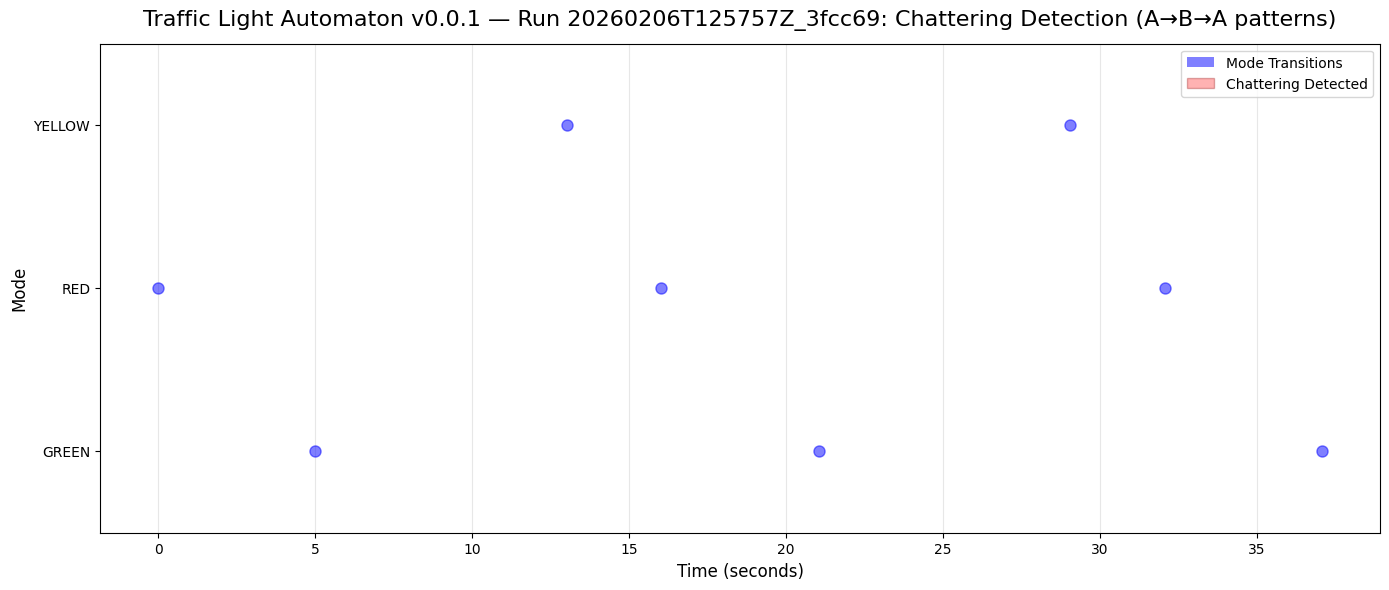

In [6]:
from matplotlib import pyplot as plt
from hybrid_automaton_evaluation.visualization import continuous_states_over_time_fig, mode_timeline_fig, mode_duration_pie_chart_fig, transition_matrix_heatmap_fig, chattering_detection_fig

fig1 = mode_timeline_fig(run_result=results)
fig2 = mode_duration_pie_chart_fig(run_result=results)
fig3 = transition_matrix_heatmap_fig(run_result=results)
fig4 = chattering_detection_fig(run_result=results)

plt.show()